### Parallel workflow

check the tablet docs before checking the code

In [30]:
from langgraph.graph import StateGraph, START, END 
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import Field, BaseModel
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
import operator

In [31]:
load_dotenv()

True

In [ ]:
# create the model
# llm = HuggingFaceEndpoint(
#     repo_id="google/gemma-2-2b-it",
#     task="text-generation"
# )

# model = ChatHuggingFace(llm=llm)

model = ChatOpenAI()

In [33]:
# Used for structured output from schema 
class EvaluateSchema(BaseModel):
    feedback: str = Field(description="A detailed feedback about the essay")
    score: int = Field(description="Score out of 10", ge=0, lt=10)

In [34]:

parser = PydanticOutputParser(pydantic_object=EvaluateSchema)

In [35]:
# Create state 
class EssayState(TypedDict):
    essay: str 
    language_feedback: str 
    analysis_feedback: str 
    clarity_feedback: str 
    overall_feedback: str 
    individual_score: Annotated[list[int],operator.add]  # since we add score to this field from multiple llm so we need reducers
    avg_score: float

In [36]:
def evaluate_language(state: EssayState):
    template = PromptTemplate(
    template= "Evaluate the language quality of the following essay.\n"
        "Provide detailed feedback and assign a score out of 10.\n\n"
        "Essay:\n{essay}\n\n"
        "{format_instruction}",

    input_variables=["essay"],
    partial_variables= {'format_instruction': parser.get_format_instructions()}
    )

    prompt = template.invoke({"essay": state['essay']})

    model_output = model.invoke(prompt)

    parsed_model_output = parser.parse(model_output.content)
    
    return {'language_feedback': parsed_model_output.feedback, 'individual_score': [parsed_model_output.score]}

In [37]:
def evaluate_analysis(state: EssayState):
    template = PromptTemplate(
    template= "Evaluate the depth of analysis of the following essay.\n"
        "Provide detailed feedback and assign a score out of 10.\n\n"
        "Essay:\n{essay}\n\n"
        "{format_instruction}",

    input_variables=["essay"],
    partial_variables= {'format_instruction': parser.get_format_instructions()}
    )

    prompt = template.invoke({"essay": state['essay']})

    model_output = model.invoke(prompt)
    parsed_model_output = parser.parse(model_output.content)
    
    return {'analysis_feedback': parsed_model_output.feedback, 'individual_score': [parsed_model_output.score]}

In [38]:
def evaluate_clarity(state: EssayState):
    template = PromptTemplate(
    template= "Evaluate the clarity of thought of the following essay.\n"
        "Provide detailed feedback and assign a score out of 10.\n\n"
        "Essay:\n{essay}\n\n"
        "{format_instruction}",

    input_variables=["essay"],
    partial_variables= {'format_instruction': parser.get_format_instructions()}
    )

    prompt = template.invoke({"essay": state['essay']})

    model_output = model.invoke(prompt)
    parsed_model_output = parser.parse(model_output.content)
    
    return {'clarity_feedback': parsed_model_output.feedback, 'individual_score': [parsed_model_output.score]}

In [39]:
def final_feedback(state: EssayState):
    prompt = f"Based on the following feedback, create a summarized feedback: \n\n clarity_feedback - {state['clarity_feedback']} \n\n analysis_feedback - {state['analysis_feedback']} \n\n language_feedback - {state['language_feedback']}"
    model_output = model.invoke(prompt)
    overall_feedback = model_output.content

    # average score 
    average_score = sum(state['individual_score']) / len(state['individual_score'])

    return {'overall_feedback': overall_feedback, 'avg_score': average_score}


In [40]:
# build graph 
graph = StateGraph(EssayState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('final_feedback',final_feedback)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','final_feedback')
graph.add_edge('evaluate_analysis','final_feedback')
graph.add_edge('evaluate_clarity','final_feedback')

graph.add_edge('final_feedback',END)

workflow = graph.compile()



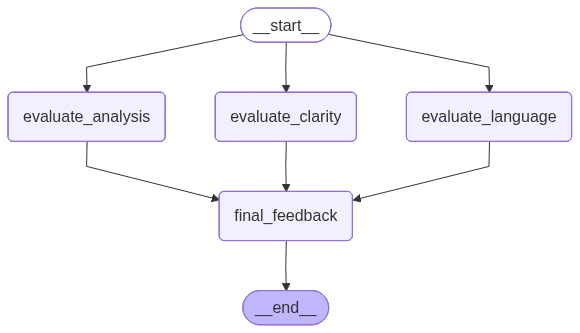

In [41]:
workflow

In [42]:
essay = """Pursuing a PhD represents my commitment to advancing knowledge and contributing meaningful insights to my field. My academic journey has been driven by curiosity, discipline, and a desire to solve complex problems. Through rigorous research, I aim to explore innovative methodologies that challenge conventional thinking and foster interdisciplinary collaboration. I believe scholarship should not only deepen understanding but also serve society. This doctoral path will refine my analytical skills, expand my intellectual horizons, and prepare me to lead impactful research. I am eager to engage with a vibrant academic community and contribute to the evolving landscape of scientific inquiry.
"""

In [49]:
initial_state = {
    'essay': essay
}

result = workflow.invoke(initial_state)
print(result)

{'essay': 'Pursuing a PhD represents my commitment to advancing knowledge and contributing meaningful insights to my field. My academic journey has been driven by curiosity, discipline, and a desire to solve complex problems. Through rigorous research, I aim to explore innovative methodologies that challenge conventional thinking and foster interdisciplinary collaboration. I believe scholarship should not only deepen understanding but also serve society. This doctoral path will refine my analytical skills, expand my intellectual horizons, and prepare me to lead impactful research. I am eager to engage with a vibrant academic community and contribute to the evolving landscape of scientific inquiry.\n', 'language_feedback': "The essay demonstrates a high level of language quality. It effectively conveys the writer's passion for research and higher education. The use of vocabulary is appropriate and sophisticated. The structure of the essay is clear and organized, leading to a coherent fl

In [50]:
print(result['overall_feedback'])
print(result['avg_score'])

Overall, the feedback highlights that the essay is clear and focused, effectively communicating the author's motivations and goals for pursuing a PhD. The analysis is strong, demonstrating a solid understanding of the importance of scholarly work, but could benefit from specific examples or personal experiences. The language quality is high, with appropriate vocabulary and a clear structure that conveys the writer's passion for research and commitment to academic excellence. Additional depth and personal insights could enhance the overall impact of the essay.
8.333333333333334
